In [3]:
# =========================
# CELL 1: IMPORTS
# =========================
import os
import sys
sys.path.append("..")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from src.data_pipeline import encode_labels, get_class_weights, make_datasets
from src.models.cnn_model import build_efficientnet
from src.train import get_callbacks

In [4]:
# =========================
# CELL 2: LOAD DATA WITH NOTEBOOK-SAFE PATHS
# =========================
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")

train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/RiceLeafs/train", regex=False
)
val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/RiceLeafs/validation", regex=False
)

train_df["full_path"] = train_df["filepath"].apply(lambda p: os.path.join("..", p))
val_df["full_path"] = val_df["filepath"].apply(lambda p: os.path.join("..", p))

train_df = train_df[train_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["full_path"].apply(os.path.exists)].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

train_df.head()

Train shape: (2684, 4)
Validation shape: (671, 4)


,filepath,label,split,full_path
0,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
1,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
2,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
3,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...
4,data/raw/RiceLeafs/train/BrownSpot/IMG_2019042...,BrownSpot,train,..\data/raw/RiceLeafs/train/BrownSpot/IMG_2019...


In [5]:
# =========================
# CELL 3: ENCODE LABELS AND BUILD DATASETS
# =========================
y_train, y_val, label_encoder, class_names = encode_labels(train_df, val_df)
class_weights = get_class_weights(y_train)
train_ds, val_ds = make_datasets(train_df, val_df, y_train, y_val)

print("Classes:", class_names)
print("Class weights:", class_weights)

Classes: ['BrownSpot' 'Healthy' 'Hispa' 'LeafBlast']
Class weights: {0: 1.605263157894737, 1: 0.563392107472712, 2: 1.4845132743362832, 3: 1.0770465489566614}


In [6]:
# =========================
# CELL 4: BUILD MODEL
# =========================
model, base_model = build_efficientnet(len(class_names))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [7]:
# =========================
# CELL 5: CALLBACKS
# =========================
model_path = "../experiments/results/best_efficientnetb0.keras"
callbacks = get_callbacks(model_path)
callbacks

In [8]:
# =========================
# CELL 6: FIRST TRAINING PHASE
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.3272 - loss: 1.7391
Epoch 1: val_loss improved from None to 1.36866, saving model to ../experiments/results/best_efficientnetb0.keras

Epoch 1: finished saving model to ../experiments/results/best_efficientnetb0.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 449ms/step - accuracy: 0.3588 - loss: 1.6533 - val_accuracy: 0.2712 - val_loss: 1.3687 - learning_rate: 1.0000e-04
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.4092 - loss: 1.4508
Epoch 2: val_loss did not improve from 1.36866
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 421ms/step - accuracy: 0.4206 - loss: 1.4201 - val_accuracy: 0.2936 - val_loss: 1.3745 - learning_rate: 1.0000e-04
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.4832 - loss: 1.2433
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.

Epoch 3: val_loss did not improve from 1.36866
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 423ms/step - accuracy: 0.4728 - loss: 1.2630 - va

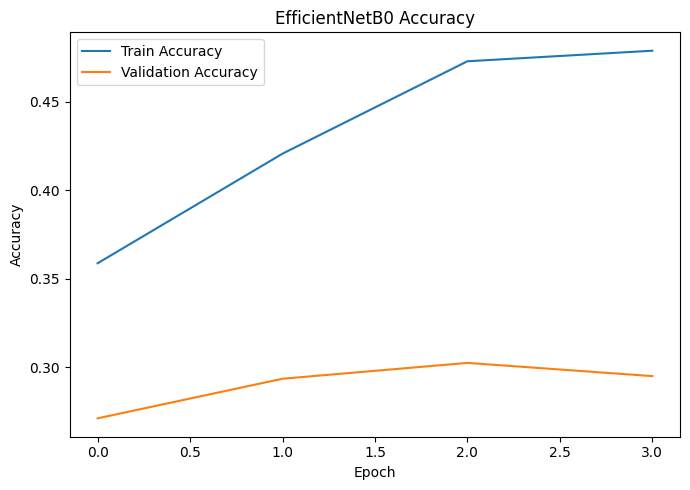

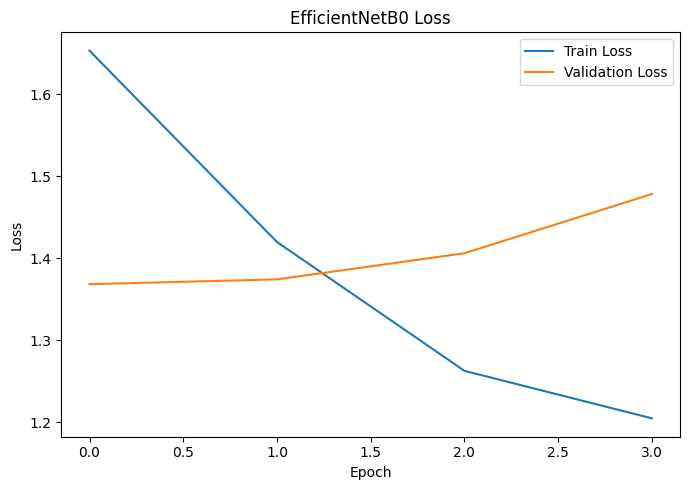

In [9]:
# =========================
# CELL 7: FIRST PHASE LEARNING CURVES
# =========================
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# =========================
# CELL 8: FINE-TUNING
# =========================
base_model.trainable = True

for layer in base_model.layers[:-150]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    initial_epoch=history.epoch[-1] + 1,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.2673 - loss: 2.0630
Epoch 5: val_loss did not improve from 1.36866
84/84 ━━━━━━━━━━━━━━━━━━━━ 83s 803ms/step - accuracy: 0.2955 - loss: 1.9271 - val_accuracy: 0.3130 - val_loss: 1.4262 - learning_rate: 1.0000e-05
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.3458 - loss: 1.6159
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 6: val_loss did not improve from 1.36866
84/84 ━━━━━━━━━━━━━━━━━━━━ 67s 800ms/step - accuracy: 0.3681 - loss: 1.5756 - val_accuracy: 0.3308 - val_loss: 1.5812 - learning_rate: 1.0000e-05
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.4008 - loss: 1.4850
Epoch 7: val_loss did not improve from 1.36866
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 813ms/step - accuracy: 0.4080 - loss: 1.4604 - val_accuracy: 0.2742 - val_loss: 1.7418 - learning_rate: 3.0000e-06
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.


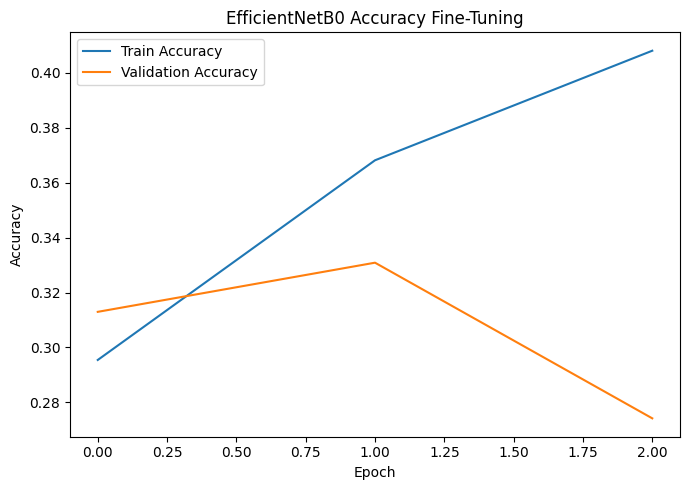

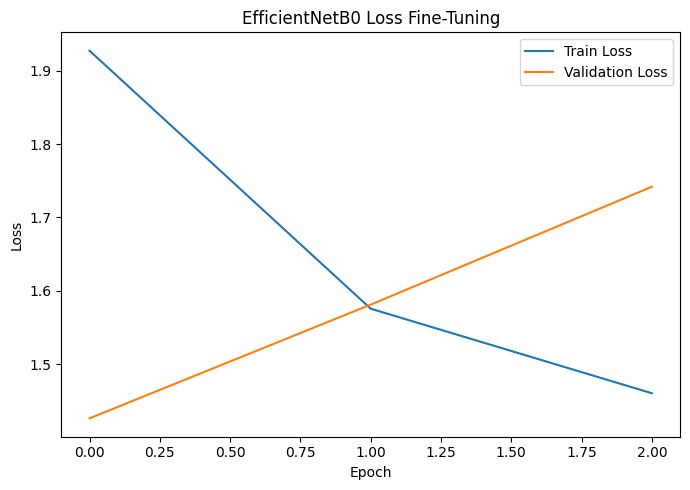

In [11]:
# =========================
# CELL 9: FINE-TUNING LEARNING CURVES
# =========================
plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history["accuracy"], label="Train Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 Accuracy Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history["loss"], label="Train Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 Loss Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# =========================
# CELL 10: LOAD SAVED TRAINING HISTORY
# =========================
history_path = Path("../experiments/logs/training_history.json")

if history_path.exists():
    with open(history_path, "r") as f:
        saved_history = json.load(f)

    history_df = pd.DataFrame(saved_history)
    history_df.head()
else:
    print("No saved training history found.")

In [13]:
# =========================
# CELL 11: LOAD FINAL EVALUATION RESULTS
# =========================
eval_csv_path = Path("../experiments/results/eval_results.csv")
eval_json_path = Path("../experiments/results/eval_metrics.json")

if eval_csv_path.exists():
    eval_results_df = pd.read_csv(eval_csv_path)
    display(eval_results_df)
else:
    print("Evaluation CSV not found.")

if eval_json_path.exists():
    with open(eval_json_path, "r") as f:
        eval_metrics = json.load(f)

    print("Evaluation Metrics:")
    print(eval_metrics)
else:
    print("Evaluation JSON not found.")

,Model,Accuracy,Macro-F1
0,EfficientNetB0,0.396423,0.354722


Evaluation Metrics:
{'accuracy': 0.39642324888226527, 'macro_f1': 0.35472174256476563}


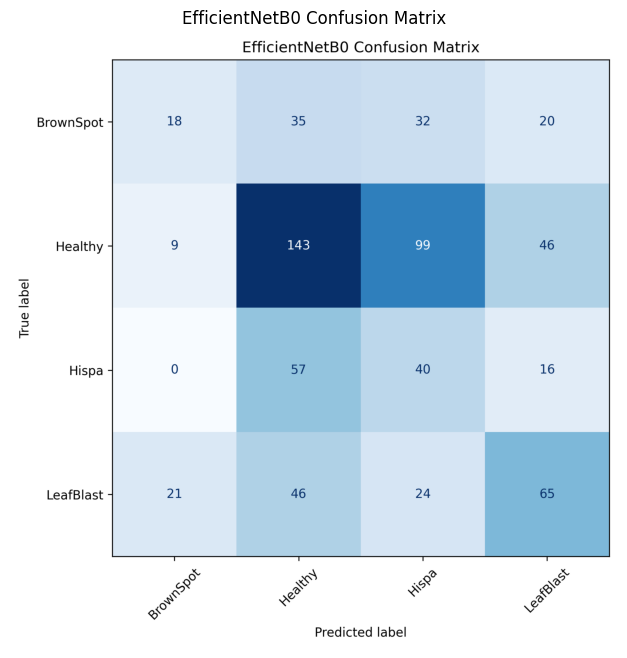

In [14]:
# =========================
# CELL 12: DISPLAY CONFUSION MATRIX IMAGE
# =========================
conf_matrix_path = Path("../experiments/results/confusion_matrix.png")

if conf_matrix_path.exists():
    img = plt.imread(conf_matrix_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("EfficientNetB0 Confusion Matrix")
    plt.show()
else:
    print("Confusion matrix image not found.")

In [15]:
# =========================
# CELL 13: SHORT SUMMARY
# =========================
print("Summary:")
print("- EfficientNetB0 was used as the CNN backbone with transfer learning.")
print("- The model was trained using class weights and fine-tuning.")
print("- Final evaluation metrics and confusion matrix are shown above.")

Summary:
- EfficientNetB0 was used as the CNN backbone with transfer learning.
- The model was trained using class weights and fine-tuning.
- Final evaluation metrics and confusion matrix are shown above.
